In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
import gurobipy as gp
from gurobipy import GRB

## RDC 생성

#### Block 별로 생성

In [4]:
#rdc 하이퍼파라메터 
wf_offer_grid = np.arange(
    0,
    20000,
    10
)

B = 500                   # stepwise 블록 개수

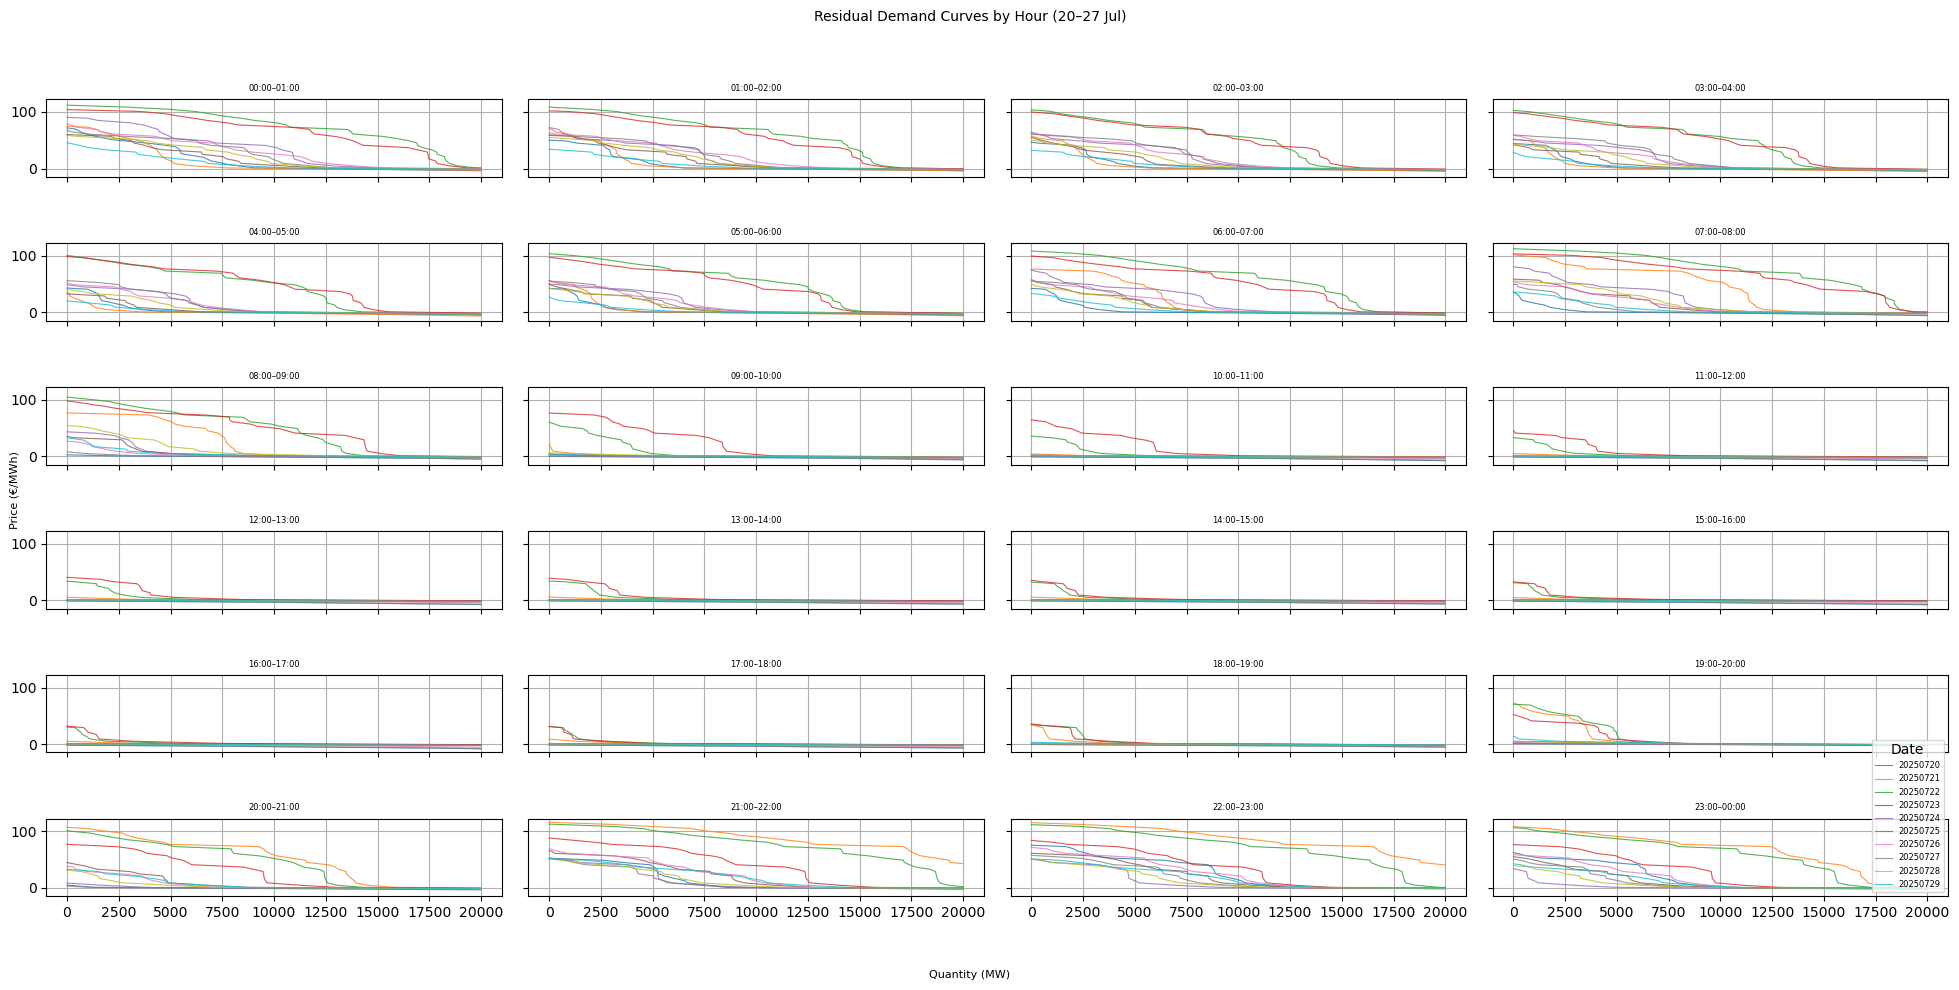

In [7]:
# --- A) RDC 계산 함수 (생략) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i], resid[i+1]
            if r1!=r0:
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q,p_star))
    return rdc

# --- B) 공통 설정 ---
days          = range(20,30)                 # 7/20~7/27
colors        = plt.cm.tab10(np.linspace(0,1,len(days)))
# wf_offer_grid = np.arange(0,20001,100)       # 0,100,…,20000
# wf_offer_grid = np.arange(0, s_agg['Cumul'].max()*1.2, 100)

# stepwise 파라미터 저장용
qini            = {}
qmax            = {}
lambda_da_block = {}
orig_cp         = {}

# --- C) 4×6 서브플롯 생성 (figsize 10×5) ---
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20,10),
                         sharex=True, sharey=True)
axes = axes.flatten()

# --- D) 각 Period(1~24) 에 대해 ---
for period in range(1,25):
    ax = axes[period-1]
    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"
        try:
            df = pd.read_csv(fn, encoding='utf-8-sig')
        except FileNotFoundError:
            continue

        # 이미 Price/Amount가 float 라고 가정
        sub    = df[df['Time Period']==period]
        sup    = sub[sub['GC']=='V']
        dem    = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        # 집계 & 누적
        # 집계 & 누적
        s_agg = sup.groupby('Price')['Amount'] \
                    .sum().reset_index() \
                    .sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = dem.groupby('Price')['Amount'] \
                    .sum().reset_index() \
                    .sort_values('Price')
        # 가격 낮을수록 누적이 커져야 하니 역순 누적
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 계단 보간
        s_f = interp1d(
            s_agg['Price'], s_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(0, s_agg['Cumul'].iat[-1])
        )
        d_f = interp1d(
            d_agg['Price'], d_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(d_agg['Cumul'].iat[0], 0)
        )

        pg  = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
        sv  = s_f(pg)
        dv  = d_f(pg)
        #Original Clearing Price 계산
        def resid0(p): 
            return d_f(p) - s_f(p)   # q=0
        sol0 = root_scalar(resid0,
                           bracket=[pg[0], pg[-1]],
                           method='bisect')
        orig_cp[(date_str, period)] = sol0.root if sol0.converged else np.nan


        # wf_offer_grid = np.arange(
        #     0,
        #     s_agg['Cumul'].max() * 1.2,
        #     100
        # )
        
        # Residual Demand
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)
        qv = np.array(qv); pv = np.array(pv)

        # ——— stepwise 근사 파라미터 계산 —————————
        q_breaks = np.linspace(0, qv.max(), B+1)
        delta_qs = q_breaks[1:] - q_breaks[:-1]
        for b in range(B):
            mid = 0.5*(q_breaks[b] + q_breaks[b+1])
            # date_str, period, block b 를 키로 사용
            qini   [(date_str, period, b)] = float(q_breaks[b])
            qmax   [(date_str, period, b)] = float(delta_qs[b])
            lambda_da_block[(date_str, period, b)] = float(np.interp(mid, qv, pv))
        # ————————————————————————————————

        # RDC Curve만 플롯
        # ax.plot(qv, pv, 'o-', color=color, label=date_str)
        ax.plot(
            qv, pv,
            '-',                # 실선만
            color=color,
            label=date_str,
            linewidth=0.8,
            alpha=0.8
        )

    # subplot 제목 (예: “00:00–01:00”)
    hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
    ax.set_title(f"{hh1}–{hh2}", fontsize=6)
    ax.grid(True)

# --- E) 공통 레이블 & 레이아웃 ---
fig.supxlabel('Quantity (MW)', fontsize=8)
fig.supylabel('Price (€/MWh)', fontsize=8)
fig.suptitle('Residual Demand Curves by Hour (20–27 Jul)', fontsize=10)

# 범례는 맨 마지막 축에만 표시하도록
axes[-1].legend(title='Date', fontsize=6, loc='lower right')

plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


## Model 3

In [8]:
# 2) ESS 파라미터
eta_c, eta_d    = 0.9, 0.9
E0, E_min, E_max = 1400, 500, 2250
pc_max, pd_max  = 500, 500

시나리오 생성

In [ ]:
'''시나리오 1: RDC 시나리오 생성'''
# 1) 날짜 및 시나리오 정의
date_range = [f"202507{d:02d}" for d in range(20, 30)]  # 20,21,…,27
S = list(range(len(date_range)))                      # 시나리오 0~7
T = list(range(1, 25))                                # 시간 1~24
I = list(range(1))                                     # 풍력 설비 0번만
J = [1,2,3,4]                      # 15분 분할
Δt = 0.25

# 시나리오 확률 (균등)
rho = {s: 1/len(S) for s in S}

# 2) RDC 시나리오 파라미터 맵 생성
qini_scen       = {}
qmax_scen       = {}
lambda_da_scen  = {}

for s, date in enumerate(date_range):
    # qini
    for (d,t,b), q in qini.items():
        if d == date:
            qini_scen[(s,t,b)] = q
    # qmax
    for (d,t,b), Δ in qmax.items():
        if d == date:
            qmax_scen[(s,t,b)] = Δ
    # lambda_da
    for (d,t,b), π in lambda_da_block.items():
        if d == date:
            lambda_da_scen[(s,t,b)] = π

# ─────────────────────────────────────────────────────────────
# 3) valid_blocks 재생성: qmax_scen 에서 t별로 Δ>0 인 b만 남김
valid_blocks = {
    t: sorted({ b
                for (s2,t2,b),Δ in qmax_scen.items()
                if t2==t and Δ>0 })
    for t in T
}

# 기존에 (s, t, b) 순서로 되어 있던 시나리오 맵을 (t, b, s) 순서로 뒤집어 재생성
qini_scen      = { (t,b,s): qini_scen[(s,t,b)]       for (s,t,b)   in qini_scen      }
qmax_scen      = { (t,b,s): qmax_scen[(s,t,b)]       for (s,t,b)   in qmax_scen      }
lambda_da_scen = { (t,b,s): lambda_da_scen[(s,t,b)]  for (s,t,b)   in lambda_da_scen }


In [10]:
# 예시로 확인해보기 (pandas로 표 형태로)
df = pd.DataFrame([
    {"t":t, "b":b, "s":s,
     "qini": q, 
     "qmax": qmax_scen[(t,b,s)],
     "lam_da": lambda_da_scen[(t,b,s)]}
    for (t,b,s), q in qini_scen.items()
])
display(df.sort_values(["t","b","s"]).head(10))


,t,b,s,qini,qmax,lam_da
0,1,0,0,0.0,39.98,71.788734
12000,1,0,1,0.0,39.98,74.851617
24000,1,0,2,0.0,39.98,112.026369
36000,1,0,3,0.0,39.98,104.176516
48000,1,0,4,0.0,39.98,90.406014
60000,1,0,5,0.0,39.98,59.987178
72000,1,0,6,0.0,39.98,78.855063
84000,1,0,7,0.0,39.98,67.255139
96000,1,0,8,0.0,39.98,58.650366
108000,1,0,9,0.0,39.98,45.356354


In [ ]:
'''시나리오 2: rt price 시나리오 생성'''
#7월 20일 기준
rt_price_15min = [
    75.78, 75.54, 72.72, 42.23, 75.30, 75.30, 61.91, 35.25, 75.30, 48.33,
    39.81, 23.08, 65.80, 49.92, 33.81, 18.07, 45.68, 35.81, 26.04, 30.98,
    32.11, 36.47, 34.14, 29.49, 27.58, 34.34, 21.44, 33.44, 26.00,  3.30,
    -1.99, -8.99, 28.79,  0.49, -5.51, -6.31,  3.52,  0.65, -1.01, -5.90,
    -0.97, -3.00, -3.00,  0.00,  0.01,  4.31,  0.00,  0.00,  0.99,  0.99,
     0.14,  0.00,  0.65,  0.65,  0.65,  0.00,  0.99,  0.00,  0.00,  0.00,
    -0.65, -0.65, -0.50, -0.65,  0.00,  0.00,  0.00, -0.01, -0.61,  0.00,
     0.00,  0.00,  0.00,  0.00,  0.00,  0.00, -9.70, -0.97, 20.33, 79.89,
    -8.99,  8.81, 49.88, 83.87, 36.84, 66.60, 72.19, 75.54, 82.80, 82.80,
    85.21, 82.01, 86.16, 78.72, 72.27, 53.31
]
rt_price_15min = 0.5 * np.array(rt_price_15min)  # 15분 단위 RT 가격
# 1) 15분 가격을 (24시간 × 4구간) 배열로 재형성
rt15_arr = np.array(rt_price_15min).reshape(24, 4)

# (t,j) → price 사전 생성
#  t=1..24,  j=1..4
lambda_rt = {
    (t, j): float(rt15_arr[t-1, j-1])
    for t in T for j in J
}
sigma_eta = 0.1  # 실시간 가격 변동성 (5%)
# λ_rt_act[(t,j,s)] : 시나리오 s의 시간 t, 구간 j 실시간 가격
lambda_rt_act = {
    (t, j, s): rt15_arr[t-1, j-1] * (1 + sigma_eta * np.random.randn())
    for t in T for j in J for s in S
}

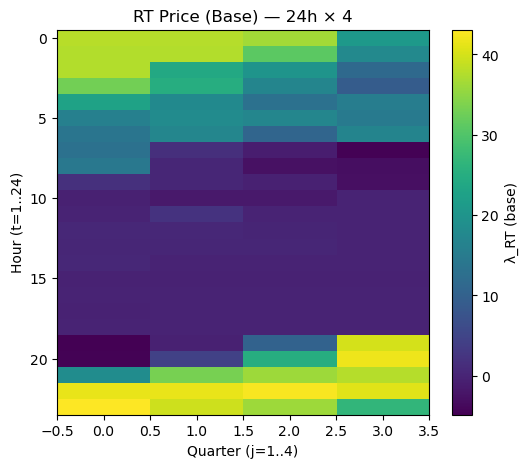

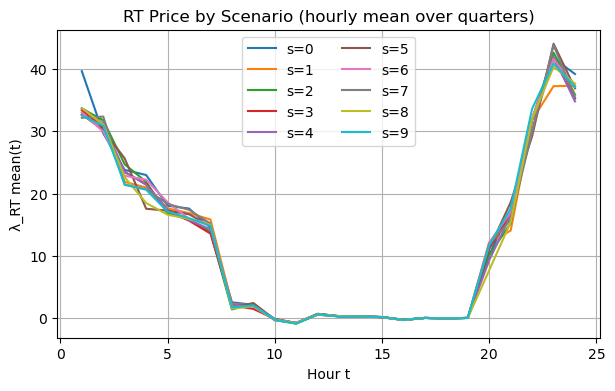

In [14]:
# --- 1) RT 기본 24x4 매트릭스 히트맵 (시나리오 잡음 전) ---
fig1 = plt.figure(figsize=(6,5))
plt.imshow(rt15_arr, aspect='auto')
plt.colorbar(label='λ_RT (base)')
plt.title('RT Price (Base) — 24h × 4')
plt.xlabel('Quarter (j=1..4)')
plt.ylabel('Hour (t=1..24)')
plt.show()

# --- 2) 시나리오별 RT(시간별 평균) 라인 플롯 ---
# j=1..4 평균을 내서 24길이 시계열로 시나리오별 비교
fig2 = plt.figure(figsize=(7,4))
for s in S:
    rt_mean_t = [np.mean([lambda_rt_act[(t,j,s)] for j in J]) for t in T]
    plt.plot(T, rt_mean_t, label=f"s={s}")
plt.title('RT Price by Scenario (hourly mean over quarters)')
plt.xlabel('Hour t')
plt.ylabel('λ_RT mean(t)')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [29]:
'''시나리오 3: wf generation 시나리오 생성'''
# 풍력 발전량 시나리오 pwf[i,t,s]
# np.random.seed(0)
# Cw = 1000
# pwf = {
#     (i,t,s): max(0, np.random.normal(Cw*0.95, Cw*0.20))
#     for i in I for t in T for s in S
# }

'시나리오 3: wf generation 시나리오 생성'

In [30]:
# sigma_frac_day = 0.05  # 하루 평균 변동성
# sigma_frac_intra = 0.02  # 시간별 작은 변동성
# mu_frac    = 0.95 
# np.random.seed(0)
# pwf = {}
# for i in I:
#     for s in S:
#         day_mean = np.random.normal(Cw*mu_frac, Cw*sigma_frac_day)
#         for t in T:
#             val = day_mean + np.random.normal(0, Cw*sigma_frac_intra)
#             pwf[(i,t,s)] = max(0, val)

In [31]:
sigma_frac = 0.05   # 5% 변동성
mu_frac    = 0.95   # 평균 95% 정격출력

np.random.seed(0)
pwf = {
    (i,t,s): max(0, np.random.normal(Cw*mu_frac, Cw*sigma_frac))
    for i in I for t in T for s in S
}

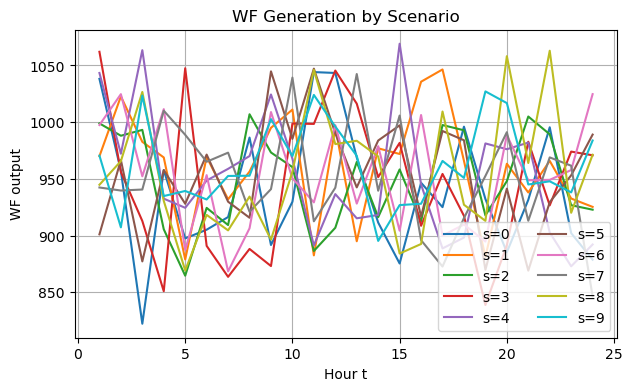

[CHECK] RT act min/max: -5.55 / 53.63,  negatives: 180개
[CHECK] WF  min/max/mean: 822.4 / 1069.2 / 952.4


In [32]:
i0 = I[0]
fig4 = plt.figure(figsize=(7,4))
for s in S:
    wf_t = [pwf[(i0,t,s)] for t in T]
    plt.plot(T, wf_t, label=f"s={s}")
plt.title('WF Generation by Scenario')
plt.xlabel('Hour t')
plt.ylabel('WF output')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

# --- 5) 빠른 통계/이상치 점검 ---
rt_all = np.array([lambda_rt_act[(t,j,s)] for t in T for j in J for s in S])
wf_all = np.array([pwf[(i0,t,s)] for t in T for s in S])

neg_rt = np.sum(rt_all < 0)
print(f"[CHECK] RT act min/max: {rt_all.min():.2f} / {rt_all.max():.2f},  negatives: {neg_rt}개")
print(f"[CHECK] WF  min/max/mean: {wf_all.min():.1f} / {wf_all.max():.1f} / {wf_all.mean():.1f}")


## Model 3

In [33]:
from itertools import product

In [50]:
from itertools import product


# 세 축의 시나리오 인덱스(각 10개씩)
S_r = list(range(10))      # RDC
S_p = list(range(10))      # RT
S_w = list(range(10))      # WF

# 1000개 조합(튜플) → 단일 인덱스 w로 번호 붙임
Omega_triplets = list(product(S_r, S_p, S_w))      # [(sr,sp,sw), ...] 길이 1000
W = list(range(len(Omega_triplets)))               # [0..999]
triplet_of = { w: Omega_triplets[w] for w in W }   # w → (sr,sp,sw)

# 확률(균등/독립 가정)
rho_w = { w: 1.0/len(W) for w in W }

# ── 1000개 결합 dict로 “평탄화” ─────────────────────────────
qini_1000      = {}
qmax_1000      = {}
lambda_da_1000 = {}
lambda_rt_1000 = {}
delta_rt_1000  = {}
pwf_1000       = {}

# RDC 결합 사전
for w in W:
    sr, sp, sw = triplet_of[w]
    for t in T:
        for b in valid_blocks[t]:
            qini_1000[(t,b,w)]      = qini_scen[(t,b,sr)]
            qmax_1000[(t,b,w)]      = qmax_scen[(t,b,sr)]
            lambda_da_1000[(t,b,w)] = lambda_da_scen[(t,b,sr)]

# RT 결합 사전
for w in W:
    sr, sp, sw = triplet_of[w]
    for t in T:
        for j in J:
            val_act = float(lambda_rt_act[(t,j,sp)])
            lambda_rt_1000[(t,j,w)] = val_act
            delta_rt_1000[(t,j,w)]  = val_act - float(lambda_rt[(t,j)])

# WF 결합 사전
for w in W:
    sr, sp, sw = triplet_of[w]
    for i in I:
        for t in T:
            pwf_1000[(i,t,w)] = pwf[(i,t,sw)]

# ── 빠른 키 검증 ─────────────────────────────────────────────
def sanity_check():
    # RDC 키
    for t in T:
        for b in valid_blocks[t]:
            for w in W:
                assert (t,b,w) in qini_1000 and (t,b,w) in qmax_1000 and (t,b,w) in lambda_da_1000
    # RT 키
    for t in T:
        for j in J:
            for w in W:
                assert (t,j,w) in lambda_rt_1000 and (t,j,w) in delta_rt_1000
    # WF 키
    for i in I:
        for t in T:
            for w in W:
                assert (i,t,w) in pwf_1000

# sanity_check()


In [52]:
model = gp.Model("WF_ESS_3D_flatW")

# ── Here-and-Now ────────────────────────────────────────────
u = model.addVars([(t,b) for t in T for b in valid_blocks[t]], vtype=GRB.BINARY, name="u")

p_hat_c = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")
u_c     = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
u_d     = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")

# ── Recourse (w별) ───────────────────────────────────────────
qvar = model.addVars([(t,b,w) for t in T for b in valid_blocks[t] for w in W], lb=0.0, name="qvar")
p_bid = model.addVars([(t,w) for t in T for w in W], lb=0.0, name="p_bid")

p_c = model.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_c")
p_d = model.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_d")
E_q = model.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max, name="E_q")
p_b = model.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_b")

# ── 목적함수 ────────────────────────────────────────────────
da_rev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        lambda_da_1000[(t,b,w)] * (u[t,b] * qini_1000[(t,b,w)] + qvar[t,b,w])
        for b in valid_blocks[t]
    )
    for w in W for t in T
)

rt_rev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        lambda_rt_1000[(t,j,w)] * (p_b[(t,j,w)] - p_bid[(t,w)]/4.0)
        for j in J for t in T
    )
    for w in W
)

model.setObjective(da_rev + rt_rev, GRB.MAXIMIZE)

# ── 제약식 ──────────────────────────────────────────────────
# (1) 블록 선택
for t in T:
    model.addConstr(gp.quicksum(u[t,b] for b in valid_blocks[t]) == 1, name=f"one_block_{t}")

# (2) qvar ≤ qmax * u (w별)
for t in T:
    for b in valid_blocks[t]:
        for w in W:
            model.addConstr(qvar[t,b,w] <= qmax_1000[(t,b,w)] * u[t,b], name=f"qvar_max_{t}_{b}_{w}")

# (3) p_bid 정의 (w별)
for t in T:
    for w in W:
        model.addConstr(
            p_bid[(t,w)] == gp.quicksum(u[t,b]*qini_1000[(t,b,w)] + qvar[t,b,w] for b in valid_blocks[t]),
            name=f"p_bid_def_{t}_{w}"
        )

# (4) 잔량 p_b = (WF/4) + p_d - p_c (w별)
for t in T:
    for j in J:
        for w in W:
            wf_t_w = gp.quicksum(pwf_1000[(i,t,w)] for i in I)
            model.addConstr(
                p_b[(t,j,w)] == (wf_t_w/4.0) + p_d[(t,j,w)] - p_c[(t,j,w)],
                name=f"p_b_def_{t}_{j}_{w}"
            )

# (5) 약속량 한계 (w별)
for t in T:
    for w in W:
        model.addConstr(-gp.quicksum(p_c[(t,j,w)] for j in J) <= p_bid[(t,w)], name=f"bid_low_{t}_{w}")
        model.addConstr(p_bid[(t,w)] <= gp.quicksum(pwf_1000[(i,t,w)] for i in I)
                                       + gp.quicksum(p_d[(t,j,w)] for j in J),
                        name=f"bid_up_{t}_{w}")

# (6) LDR (delta_rt_1000 사용, w별)
for t in T:
    for j in J:
        for w in W:
            model.addConstr(
                p_c[(t,j,w)] == u_c[(t,j)] * ( p_hat_c[(t,j)] + D_c[(t,j)] * delta_rt_1000[(t,j,w)] ),
                name=f"LDR_pc_{t}_{j}_{w}"
            )
            model.addConstr(
                p_d[(t,j,w)] == u_d[(t,j)] * ( p_hat_d[(t,j)] + D_d[(t,j)] * delta_rt_1000[(t,j,w)] ),
                name=f"LDR_pd_{t}_{j}_{w}"
            )

# (7) 충·방전 동시 금지 & Big‑M (w별)
for t in T:
    for j in J:
        model.addConstr(u_c[(t,j)] + u_d[(t,j)] <= 1, name=f"no_simul_{t}_{j}")
        for w in W:
            model.addConstr(p_c[(t,j,w)] <= pc_max * u_c[(t,j)], name=f"pc_bigm_{t}_{j}_{w}")
            model.addConstr(p_d[(t,j,w)] <= pd_max * u_d[(t,j)], name=f"pd_bigm_{t}_{j}_{w}")

# (8) SOC 전이 (w별)
for w in W:
    for t in T:
        for j in J:
            prev = (E0 if (t==1 and j==1) else (E_q[(t-1,4,w)] if j==1 else E_q[(t,j-1,w)]))
            model.addConstr(
                E_q[(t,j,w)] == prev + Δt*(eta_c*p_c[(t,j,w)] - p_d[(t,j,w)]/eta_d),
                name=f"SOC_{t}_{j}_{w}"
            )

# ── 최적화 ──────────────────────────────────────────────────
model.optimize()


Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 12456120 rows, 12420576 columns and 49307192 nonzeros
Model fingerprint: 0xb10ba651
Model has 192000 quadratic constraints
Variable types: 12408384 continuous, 12192 integer (12192 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+04]
  QMatrix range    [2e-05, 2e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e-08, 3e+05]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 24000 rows and 106295 columns (presolve time = 5s) ...
Presolve removed 10283000 rows and 10365295 columns
Presolve time: 9.12s
Presolved: 2365816 rows, 2056325 columns, 8586673 nonzeros
Presolved model has 696 SOS constraint(s)
Variable types: 2054044 continuous, 2281 integer (2281 binary)
Determi

GurobiError: Out of memory

시도1

In [43]:

S_r = list(range(10))  # RDC 시나리오 인덱스
S_p = list(range(10))  # RT  시나리오 인덱스
S_w = list(range(10))  # WF  시나리오 인덱스

Omega = list(product(S_r, S_p, S_w))  # 1000개 결합 시나리오
rho_omega = {w: 1/len(Omega) for w in Omega}  # 독립/균등 가정

# 헬퍼: 튜플 해체
def sr_of(w): return w[0]   # RDC
def sp_of(w): return w[1]   # RT
def sw_of(w): return w[2]   # WF

delta_rt = {
    (t,j,sp): float(lambda_rt_act[(t,j,sp)] - lambda_rt[(t,j)])
    for t in T for j in J for sp in S_p
}

In [44]:
model = gp.Model("WF_ESS_3D_RDC_RT_WF")

# 1단계 (공통)
u    = model.addVars([(t,b) for t in T for b in valid_blocks[t]], vtype=GRB.BINARY, name="u")

# RDC-시나리오(=sr) recourse (DA 쪽)
qvar = model.addVars([(t,b,sr) for t in T for b in valid_blocks[t] for sr in S_r],
                     lb=0.0, name="qvar")
p_bid= model.addVars([(t,sr) for t in T for sr in S_r], lb=0.0, name="p_bid")

# ESS here-and-now 모드변수(선택): 충/방전 동시금지 위한 on/off (공통)
u_c  = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
u_d  = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")

# ESS/실제운영: 공동시나리오(=ω)별
p_c  = model.addVars([(t,j,w) for t in T for j in J for w in Omega], lb=0.0, ub=pc_max, name="p_c")
p_d  = model.addVars([(t,j,w) for t in T for j in J for w in Omega], lb=0.0, ub=pd_max, name="p_d")
E_q  = model.addVars([(t,j,w) for t in T for j in J for w in Omega], lb=E_min, ub=E_max, name="E_q")
p_b  = model.addVars([(t,j,w) for t in T for j in J for w in Omega], lb=0.0, name="p_b")

# (선택) LDR 계수 (공통). delta_rt는 sp에 의존.
p_hat_c = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

In [49]:
# DA revenue (결합 시나리오의 sr만 관여)
da_rev = gp.quicksum(
    rho_omega[w] *
    gp.quicksum(
        lambda_da_scen[(t,b, sr_of(w))] * (u[t,b] * qini_scen[(t,b, sr_of(w))] + qvar[t,b,w])
        for b in valid_blocks[t]
    )
    for w in Omega for t in T
)

# RT revenue (결합 시나리오의 sp만 관여; p_b와 p_bid는 각 w별)
rt_rev = gp.quicksum(
    rho_omega[w] *
    gp.quicksum(
        lambda_rt_act[(t,j, sp_of(w))] * ( p_b[(t,j,w)] - p_bid[(t,w)]/4.0 )
        for j in J for t in T
    )
    for w in Omega
)

model.setObjective(da_rev + rt_rev, GRB.MAXIMIZE)

# 4.1) 블록 선택(Here-and-Now): 매 시각 하나 선택
for t in T:
    model.addConstr(gp.quicksum(u[t,b] for b in valid_blocks[t]) == 1, name=f"one_block_{t}")

# 4.2) qvar ≤ qmax * u  (RDC 시나리오별 recourse)
for t in T:
    for b in valid_blocks[t]:
        for w in Omega:
            sr = sr_of(w)   # ← 반드시 int
            model.addConstr(qvar[t,b,w] <= qmax_scen[(t,b,sr)] * u[t,b],
                            name=f"qvar_max_{t}_{b}_sr{sr}")

# 4.3) p_bid 정의 (RDC에 종속: sr)
for t in T:
    for w in Omega:
        sr = sr_of(w)
        model.addConstr(
            p_bid[(t,w)] == gp.quicksum(u[t,b]*qini_scen[(t,b,sr)] + qvar[t,b,w]
                                        for b in valid_blocks[t]),
            name=f"p_bid_def_{t}_sr{sr}"
        )

# 4.4) 잔량 p_b 정의: WF(sw) & ESS 결정 반영
for t in T:
    for j in J:
        for w in Omega:
            sw = sw_of(w)
            wf_t_sw = gp.quicksum(pwf[(i,t,sw)] for i in I)  # 시간 t 풍력 총합(시나리오 sw)
            model.addConstr(
                p_b[(t,j,w)] == (wf_t_sw/4.0) + p_d[(t,j,w)] - p_c[(t,j,w)],
                name=f"p_b_def_{t}_{j}_sw{sw}"
            )

# 4.5) DA vs RT 약속량 한계 (각 결합 시나리오별)
for t in T:
    for w in Omega:
        model.addConstr(-gp.quicksum(p_c[(t,j,w)] for j in J) <= p_bid[(t,w)],
                        name=f"bid_low_{t}_w")
        model.addConstr(p_bid[(t,w)] <= gp.quicksum(pwf[(i,t, sw_of(w))] for i in I)
                                      + gp.quicksum(p_d[(t,j,w)] for j in J),
                        name=f"bid_up_{t}_w")

# 4.6) LDR: p_c, p_d (결합 시나리오별, RT sp 사용)
for t in T:
    for j in J:
        for w in Omega:
            sp = sp_of(w)
            model.addConstr(
                p_c[(t,j,w)] == u_c[(t,j)] * ( p_hat_c[(t,j)] + D_c[(t,j)] * delta_rt[(t,j,sp)] ),
                name=f"LDR_pc_{t}_{j}_sp{sp}"
            )
            model.addConstr(
                p_d[(t,j,w)] == u_d[(t,j)] * ( p_hat_d[(t,j)] + D_d[(t,j)] * delta_rt[(t,j,sp)] ),
                name=f"LDR_pd_{t}_{j}_sp{sp}"
            )

# 4.7) 충·방전 동시 금지 & Big-M
for t in T:
    for j in J:
        model.addConstr(u_c[(t,j)] + u_d[(t,j)] <= 1, name=f"no_simul_{t}_{j}")
        model.addConstr(p_c[(t,j,w)] <= pc_max * u_c[(t,j)], name=f"pc_bigm_{t}_{j}_{0}")  # w별 복수 생성 방지용은 아래 루프에서 처리
        model.addConstr(p_d[(t,j,w)] <= pd_max * u_d[(t,j)], name=f"pd_bigm_{t}_{j}_{0}")

# 4.8) SOC 동적 전이 (결합 시나리오별)
for w in Omega:
    for t in T:
        for j in J:
            prev = (E0 if (t==1 and j==1) else
                    (E_q[(t-1,4,w)] if j==1 else E_q[(t,j-1,w)]))
            model.addConstr(
                E_q[(t,j,w)] == prev + Δt*(eta_c*p_c[(t,j,w)] - p_d[(t,j,w)]/eta_d),
                name=f"SOC_{t}_{j}_w"
            )

# ===============================================
model.optimize()

KeyError: (1, 0, (0, 0, 0))